# CIFAR-10 EDA Analysis using PyTorch + torchvision

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torchvision.datasets as datasets
import torchvision.models as models
from torchvision.models import resnet18

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from collections import Counter


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## 1. Data transforms and loaders

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:13<00:00, 13.0MB/s]


In [ ]:
classes = train_dataset.classes
print("Classes:", classes)
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train size: 50000
Test size: 10000


In [ ]:
# --- Basic label distribution ---
train_labels = [label for _, label in train_dataset]
test_labels = [label for _, label in test_dataset]

train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

print("Train label counts:", train_counts)
print("Test label counts:", test_counts)

Train label counts: Counter({6: 5000, 9: 5000, 4: 5000, 1: 5000, 2: 5000, 7: 5000, 8: 5000, 3: 5000, 5: 5000, 0: 5000})
Test label counts: Counter({3: 1000, 8: 1000, 0: 1000, 6: 1000, 1: 1000, 9: 1000, 5: 1000, 7: 1000, 4: 1000, 2: 1000})


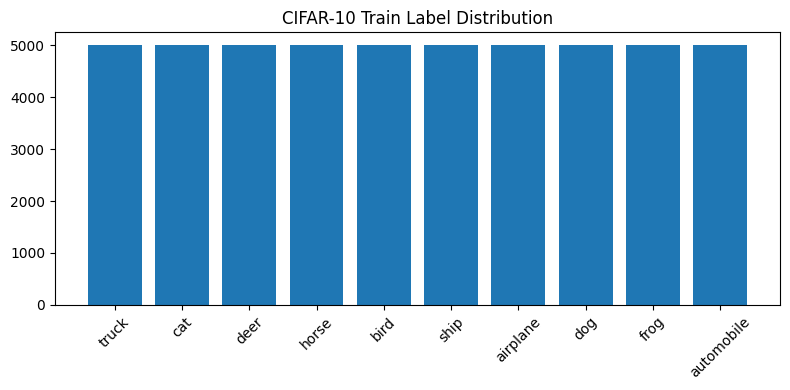

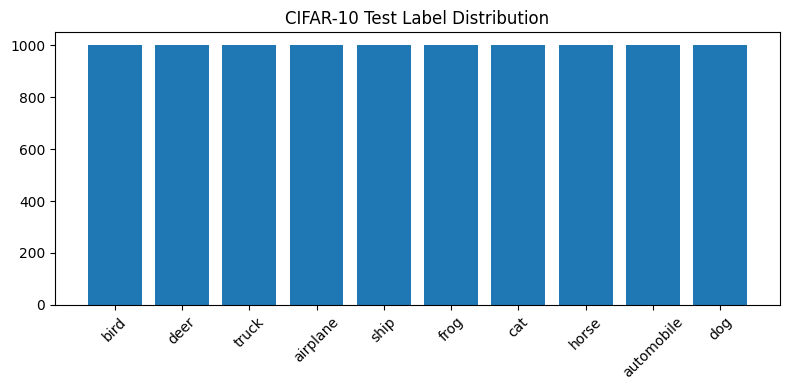

In [ ]:
# --- Plot label distribution ---
def plot_label_distribution(counts, title):
    labels = list(counts.keys())
    values = [counts[k] for k in labels]
    plt.figure(figsize=(8, 4))
    plt.bar(labels, values)
    plt.xticks(labels, classes, rotation=45)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_label_distribution(train_counts, "CIFAR-10 Train Label Distribution")
plot_label_distribution(test_counts, "CIFAR-10 Test Label Distribution")

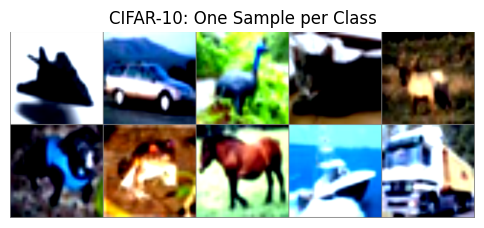

CIFAR-10 train subset mean: tensor([0.0273, 0.1135, 0.1710])
CIFAR-10 train subset std: tensor([1.0560, 1.0662, 1.1449])


In [ ]:
# --- Show sample images per class ---
def imshow(img, title=None):
    img = img / 2 + 0.5 if img.max() > 1 else img  # unnormalize if needed
    npimg = img.numpy()
    plt.figure(figsize=(6, 6))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

# one sample per class
idx_by_class = {c: None for c in range(len(classes))}
for i, (_, label) in enumerate(train_dataset):
    if idx_by_class[label] is None:
        idx_by_class[label] = i
    if all(v is not None for v in idx_by_class.values()):
        break

images = torch.stack([train_dataset[i][0] for i in idx_by_class.values()])
titles = [classes[c] for c in idx_by_class.keys()]
imshow(torchvision.utils.make_grid(images, nrow=5), title="CIFAR-10: One Sample per Class")

# --- Image statistics (per-channel mean/std) ---
all_imgs = torch.stack([img for img, _ in torch.utils.data.Subset(train_dataset, range(5000))])  # subset for speed
mean = all_imgs.mean(dim=[0, 2, 3])
std = all_imgs.std(dim=[0, 2, 3])
print("CIFAR-10 train subset mean:", mean)
print("CIFAR-10 train subset std:", std)

# 2. Pretrained model as feature extractor

In [ ]:
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Identity()  # remove final classification layer
resnet = resnet.to(device)
resnet.eval()

@torch.no_grad()
def extract_features(dataloader):
    features_list = []
    labels_list = []
    for imgs, labels in dataloader:
        imgs = imgs.to(device)
        feats = resnet(imgs)              # [batch, 512]
        feats = feats.cpu().numpy()
        features_list.append(feats)
        labels_list.append(labels.numpy())
    X = np.concatenate(features_list, axis=0)
    y = np.concatenate(labels_list, axis=0)
    return X, y

print("Extracting train features...")
X_train, y_train = extract_features(train_loader)
print("Extracting test features...")
X_test, y_test = extract_features(test_loader)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 222MB/s]


Extracting train features...
Extracting test features...


In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (50000, 512)
y_train shape: (50000,)
X_test shape: (10000, 512)
y_test shape: (10000,)


In [ ]:
df_train = pd.DataFrame(X_train)
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
0,0.000000,0.033261,0.464184,0.000000,0.341320,1.288761,0.747154,1.469309,0.019424,2.319229,...,0.356497,0.390544,0.264090,0.477061,0.000000,0.742640,0.818258,0.097199,0.217451,0.039557
1,0.642749,0.434895,0.101286,0.039378,1.077030,1.567238,2.261874,1.684240,0.142010,0.039953,...,0.062982,0.511244,0.148988,0.815239,0.000000,0.017379,0.618544,0.000000,0.463638,0.047689
2,0.000000,0.155228,0.423541,1.209370,1.080064,1.065699,1.339101,3.577127,0.066545,0.070936,...,0.421076,0.210362,0.058982,0.122675,0.036102,0.163881,0.091403,0.018335,1.183696,0.156934
3,0.783631,0.081370,0.372744,0.201306,0.116322,0.404303,0.744514,0.400050,0.081647,0.680195,...,0.033466,0.000748,0.010235,0.340887,0.039253,0.005602,0.368892,0.000000,0.012445,0.517794
4,0.633942,1.057671,1.482909,2.027587,0.813628,0.584291,0.602504,0.571914,0.000000,0.930737,...,0.444201,0.043968,0.629084,0.106169,0.113544,0.088368,1.023766,0.123416,0.483044,0.135314


In [ ]:
df_test = pd.DataFrame(X_test)
df_test.head()

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
0,0.682702,1.887017,0.645879,0.191751,0.221442,0.376718,3.643985,0.514798,0.160544,0.875996,...,0.376712,0.107968,0.315602,0.623003,0.011217,1.450132,0.923452,0.028194,0.001799,0.747395
1,0.094469,2.482641,0.396869,0.608448,1.141410,0.330849,0.462927,1.518989,0.492015,0.787293,...,0.184139,0.446718,0.000000,0.195830,0.212996,0.593640,0.967358,0.115546,1.327831,0.915541
2,0.032975,1.635103,0.713688,0.194797,1.698546,0.931358,1.135562,1.955319,1.685405,0.587056,...,0.014404,0.947343,0.121216,0.396549,0.241342,0.268362,1.375406,1.497062,1.102038,0.120154
3,0.401924,1.219280,0.070143,1.020126,0.510366,0.184706,2.436036,2.566072,0.061469,0.561709,...,0.077772,1.021838,0.030408,0.324737,0.142539,0.863440,1.160091,1.494766,0.418560,1.481640
4,0.172467,1.033720,0.772753,1.880634,0.706436,0.749864,0.040206,0.213475,0.025258,0.037153,...,0.864968,0.081315,0.845969,0.218046,0.437074,0.417639,0.220654,0.000000,0.000000,0.367367


In [ ]:
df_train.describe()

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.469783,0.876558,0.823871,0.381841,0.487426,0.567767,1.059600,0.857816,0.342176,0.918681,...,0.367865,0.482628,0.271908,0.479802,0.102459,0.632055,0.881698,0.279370,0.525158,0.461230
std,0.624468,0.804450,0.650614,0.535717,0.543788,0.564829,0.883952,0.777360,0.396664,0.850207,...,0.368064,0.480399,0.378421,0.436652,0.166753,0.555008,0.760958,0.348833,0.746961,0.530064
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.060472,0.252116,0.328805,0.038945,0.072755,0.141008,0.386595,0.289268,0.055117,0.293776,...,0.088084,0.109936,0.017173,0.141873,0.002302,0.201262,0.299174,0.037057,0.087117,0.073545
50%,0.252180,0.643490,0.677850,0.184142,0.298027,0.391503,0.851811,0.656324,0.201139,0.679784,...,0.256888,0.336798,0.118143,0.364788,0.035364,0.488276,0.690515,0.155632,0.267236,0.275161
75%,0.636203,1.285795,1.162437,0.511429,0.728409,0.825438,1.508897,1.208561,0.493215,1.285569,...,0.535554,0.715833,0.376572,0.697353,0.129347,0.920003,1.257164,0.391500,0.626221,0.664668
max,6.855708,5.981279,6.656772,7.284843,4.309900,5.599685,9.471494,10.034665,3.569390,8.663835,...,3.460086,3.870916,4.076572,3.544404,2.060549,5.470327,6.876699,4.832705,7.206088,4.515804


In [ ]:
df_test.describe()

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.477841,0.886344,0.823122,0.376589,0.484643,0.573661,1.061294,0.850230,0.342558,0.908651,...,0.367230,0.479666,0.270215,0.489434,0.101359,0.626219,0.878895,0.282028,0.520492,0.462374
std,0.644479,0.826046,0.643791,0.529466,0.548863,0.568795,0.884929,0.766371,0.390528,0.833140,...,0.374365,0.480471,0.375466,0.444977,0.168196,0.550292,0.767718,0.352436,0.734961,0.530159
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.065074,0.248334,0.333159,0.039149,0.071495,0.143468,0.392289,0.286389,0.060950,0.297391,...,0.085870,0.108114,0.015558,0.144805,0.001964,0.194490,0.295485,0.036038,0.086291,0.070530
50%,0.255686,0.644990,0.679466,0.178547,0.292704,0.397806,0.844081,0.653550,0.207327,0.668316,...,0.251458,0.332171,0.112725,0.372339,0.033584,0.484282,0.689650,0.156145,0.265989,0.278702
75%,0.641740,1.286696,1.162152,0.500353,0.716864,0.833001,1.502711,1.192033,0.487541,1.285138,...,0.534167,0.704219,0.377103,0.720959,0.127674,0.920295,1.253627,0.400813,0.620351,0.678176
max,8.127551,5.766522,4.726523,5.935354,4.949623,4.980037,6.961461,7.280425,3.303176,6.777766,...,3.662655,3.292173,3.459347,3.178718,1.776754,3.871068,5.976841,4.290079,7.526555,4.331466


In [ ]:
print("Missing values in X_train:", df_train.isna().sum().sum())
print("Missing values in X_test:", df_test.isna().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [ ]:
unique, counts = np.unique(y_train, return_counts=True)
print("Train label distribution:", dict(zip(unique, counts)))

unique, counts = np.unique(y_test, return_counts=True)
print("Test label distribution:", dict(zip(unique, counts)))

Train label distribution: {np.int64(0): np.int64(5000), np.int64(1): np.int64(5000), np.int64(2): np.int64(5000), np.int64(3): np.int64(5000), np.int64(4): np.int64(5000), np.int64(5): np.int64(5000), np.int64(6): np.int64(5000), np.int64(7): np.int64(5000), np.int64(8): np.int64(5000), np.int64(9): np.int64(5000)}
Test label distribution: {np.int64(0): np.int64(1000), np.int64(1): np.int64(1000), np.int64(2): np.int64(1000), np.int64(3): np.int64(1000), np.int64(4): np.int64(1000), np.int64(5): np.int64(1000), np.int64(6): np.int64(1000), np.int64(7): np.int64(1000), np.int64(8): np.int64(1000), np.int64(9): np.int64(1000)}


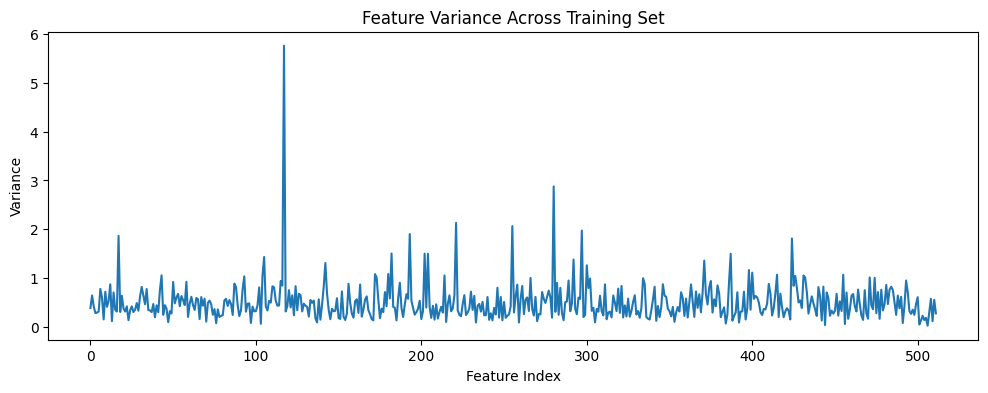

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(np.var(X_train, axis=0))
plt.title("Feature Variance Across Training Set")
plt.xlabel("Feature Index")
plt.ylabel("Variance")
plt.show()

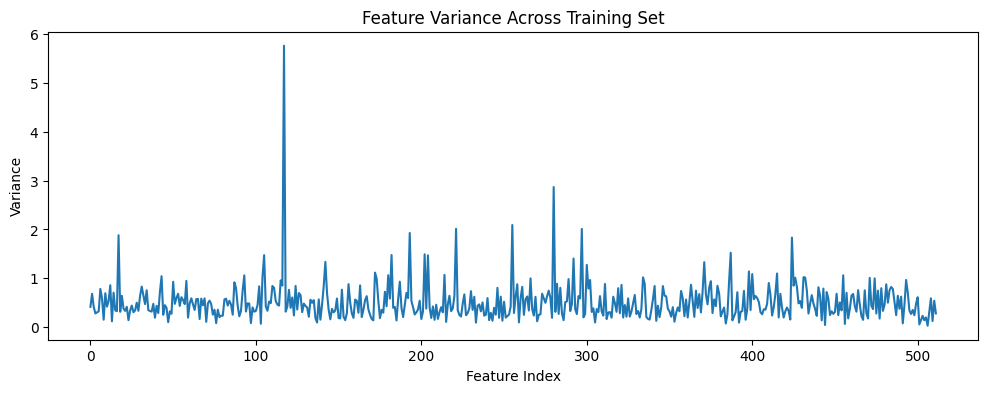

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(np.var(X_test, axis=0))
plt.title("Feature Variance Across Training Set")
plt.xlabel("Feature Index")
plt.ylabel("Variance")
plt.show()

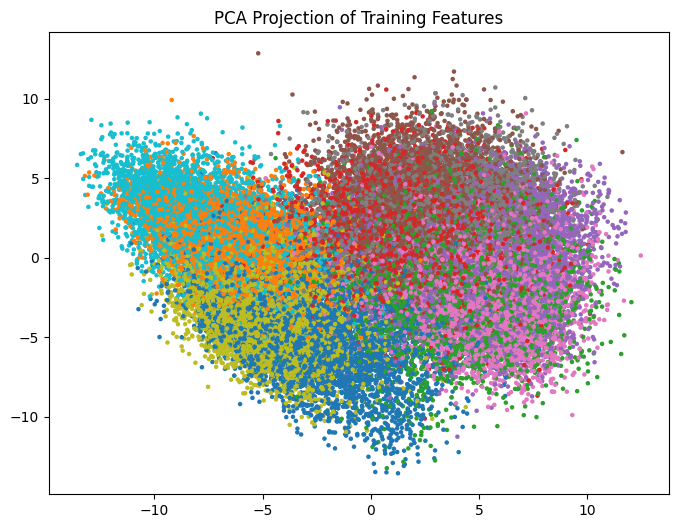

In [ ]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, s=5, cmap='tab10')
plt.title("PCA Projection of Training Features")
plt.show()

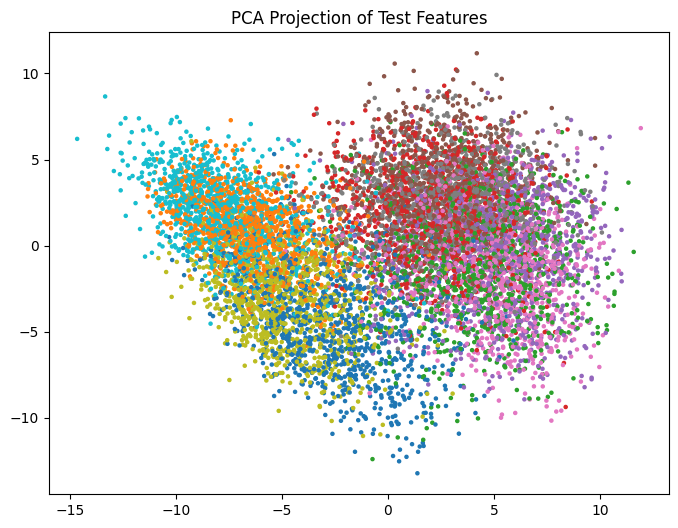

In [ ]:
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

plt.figure(figsize=(8,6))
plt.scatter(X_test_pca[:,0], X_test_pca[:,1], c=y_test, s=5, cmap='tab10')
plt.title("PCA Projection of Test Features")
plt.show()

# 3. Hyperparameter tuning on feature-level classifier

In [ ]:
param_grid = {
    "clf__C": [0.01, 0.1, 1.0, 10.0],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
    "clf__max_iter": [500]
}

pipe = Pipeline([ ("scaler", StandardScaler()), ("clf", LogisticRegression()) ])
#log_reg = LogisticRegression()
grid = GridSearchCV(pipe, param_grid, cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
best_clf = grid.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'clf__C': 0.01, 'clf__max_iter': 500, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


# 4. Evaluation

In [ ]:
y_pred = best_clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=train_dataset.classes))

              precision    recall  f1-score   support

    airplane       0.89      0.90      0.89      1000
  automobile       0.93      0.94      0.93      1000
        bird       0.85      0.82      0.83      1000
         cat       0.78      0.77      0.78      1000
        deer       0.83      0.86      0.84      1000
         dog       0.84      0.81      0.83      1000
        frog       0.88      0.92      0.90      1000
       horse       0.90      0.88      0.89      1000
        ship       0.91      0.93      0.92      1000
       truck       0.94      0.93      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



# 5. Simple feature analysis (coefficients)
### Coefficients shape: [num_classes, feature_dim]

In [ ]:
#coef = best_clf.coef_  # (10, 512)
coef = best_clf.named_steps["clf"].coef_
print("Coefficient matrix shape:", coef.shape)

Coefficient matrix shape: (10, 512)


# Example: magnitude of coefficients per feature (overall importance)

In [ ]:
feature_importance = np.mean(np.abs(coef), axis0 := 0)
topk = 20
top_features_idx = np.argsort(feature_importance)[-topk:][::-1]

print(f"Top {topk} most important feature indices (in ResNet feature space):")
print(top_features_idx)
print("Their importance values:")
print(feature_importance[top_features_idx])

Top 20 most important feature indices (in ResNet feature space):
[481 102  32 464 440 375 476 182 187 374 261 179  43 485 221 127 484 193
 138  28]
Their importance values:
[0.1436517  0.13894971 0.11988506 0.11751182 0.11586308 0.11395975
 0.11248259 0.11022865 0.10555368 0.10538073 0.10535418 0.10272666
 0.10248662 0.1022855  0.10202883 0.10108628 0.100758   0.10043728
 0.10028606 0.09951949]
